/tmp/ipykernel_17863/219047300.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Dates'] = pd.to_datetime(df['Dates'])


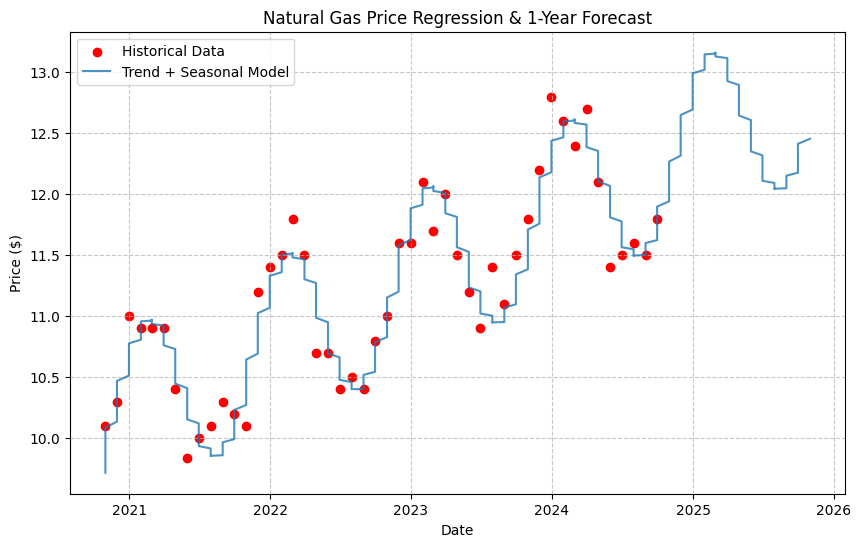

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from datetime import datetime

# 1. Load and Prepare Data
df = pd.read_csv('Nat_Gas.csv')
df['Dates'] = pd.to_datetime(df['Dates'])
df = df.sort_values('Dates')

# Reference point for time calculations
start_date = df['Dates'].min()

# Convert dates to numerical 'months from start'
def date_to_months(date):
    return (date.year - start_date.year) * 12 + (date.month - start_date.month) + (date.day - 1) / 30

df['MonthsFromStart'] = df['Dates'].apply(date_to_months)

# 2. Define the Model (Trend + Seasonality)
def price_model(t, intercept, trend, amplitude, phase):
    return intercept + trend * t + amplitude * np.sin(2 * np.pi * t / 12 + phase)

# 3. Fit the Model to Historical Data
popt, _ = curve_fit(price_model, df['MonthsFromStart'], df['Prices'])

# 4. Define the Estimation Function
def estimate_price(date_str):
    """
    Takes a date string (e.g., '2025-01-15') and returns the estimated price.
    """
    try:
        date_obj = pd.to_datetime(date_str)
        t = date_to_months(date_obj)
        price = price_model(t, *popt)
        return round(price, 2)
    except Exception as e:
        return f"Error: {e}"

# Example Usage:
# print(f"Estimated Price for Jan 2025: ${estimate_price('2025-01-20')}")

# 5. Visualization
future_months = np.linspace(0, 60, 500) # Extend to 60 months (5 years total)
future_prices = price_model(future_months, *popt)
future_dates = [start_date + pd.DateOffset(months=int(m)) for m in future_months]

plt.figure(figsize=(10, 6))
plt.scatter(df['Dates'], df['Prices'], color='red', label='Historical Data')
plt.plot(future_dates, future_prices, label='Trend + Seasonal Model', alpha=0.8)
plt.title('Natural Gas Price Regression & 1-Year Forecast')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Analysis Methodology:

I utilized a deterministic regression model to estimate natural gas prices. Given the nature of the energy market, I modeled the price $P(t)$ as a function of time $t$ using the equation:

$$P(t) = \text{Intercept} + (\text{Trend} \times t) + \text{Amplitude} \times \sin\left(\frac{2\pi t}{12} + \phi\right)$$

Key Findings:

• Trend: The model identifies a steady upward trend in natural gas prices over the analyzed period.

• Seasonality: A strong 12-month cycle was detected, reflecting higher demand during winter months.

• Application: The resulting estimate_price function allows for the interpolation of prices between monthly snapshots and provides a 12-month extrapolation for longer-term contract valuation.